In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, confusion_matrix

In [2]:
DATASET_PATH = r"C:\Users\samsung\OneDrive\바탕 화면\휴먼 프로젝트\audio"
CLASS_NAMES = ["Bee", "Hornet", "Normal"]

# 오디오 feature 추출 함수

In [3]:
def extract_features(file_path, sr=22050):
    try:
        # 파일 전체 로드
        y, sr = librosa.load(file_path, sr=sr, mono=True)

        # 빈 파일 방어
        if y is None or len(y) == 0:
            print(f"[스킵] 빈 오디오 파일: {file_path}")
            return None

        # NaN, Inf 방어
        if not np.isfinite(y).all():
            print(f"[스킵] 비정상 값 포함 파일: {file_path}")
            return None

        # 너무 짧은 경우만 패딩
        # n_fft 기본값(2048)보다 짧으면 feature 계산이 불안정해서 보정
        if len(y) < 2048:
            y = np.pad(y, (0, 2048 - len(y)), mode="constant")

        # MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        # Spectral centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        sc_mean = np.mean(spectral_centroid)
        sc_std = np.std(spectral_centroid)

        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        zcr_std = np.std(zcr)

        # RMS energy
        rms = librosa.feature.rms(y=y)
        rms_mean = np.mean(rms)
        rms_std = np.std(rms)

        # Spectral bandwidth
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        bw_mean = np.mean(bandwidth)
        bw_std = np.std(bandwidth)

        # Roll-off
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        rolloff_mean = np.mean(rolloff)
        rolloff_std = np.std(rolloff)

        feature_vector = np.hstack([
            mfcc_mean, mfcc_std,
            sc_mean, sc_std,
            zcr_mean, zcr_std,
            rms_mean, rms_std,
            bw_mean, bw_std,
            rolloff_mean, rolloff_std
        ])

        return feature_vector

    except Exception as e:
        print(f"파일 처리 오류: {file_path}, {e}")
        return None


# 데이터셋 로딩

In [4]:
features = []
true_labels = []
file_names = []

label_map = {
    "Bee": 0,
    "Hornet": 1,
    "Normal": 2
}

for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATASET_PATH, class_name)

    if not os.path.exists(class_dir):
        print(f"폴더 없음: {class_dir}")
        continue

    for file in os.listdir(class_dir):
        if file.lower().endswith(".wav"):
            file_path = os.path.join(class_dir, file)
            feat = extract_features(file_path)

            if feat is not None:
                features.append(feat)
                true_labels.append(label_map[class_name])
                file_names.append(file)

print(f"추출 성공 파일 수: {len(features)}")

if len(features) == 0:
    raise ValueError("feature가 하나도 추출되지 않았습니다. 오디오 파일 상태를 확인하세요.")

X = np.array(features)
y_true = np.array(true_labels)

print("데이터 shape:", X.shape)
print("라벨 개수:", len(y_true))


c:\Users\samsung\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

# 정규화

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans 분석

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

print("\n[KMeans 결과]")
print("Cluster labels:", np.unique(clusters_kmeans))

# silhouette score
sil_score = silhouette_score(X_scaled, clusters_kmeans)
print("Silhouette Score:", sil_score)

c:\Users\samsung\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\samsung\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\samsung\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\samsung\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\samsung\AppData\Loca


[KMeans 결과]
Cluster labels: [0 1 2]
Silhouette Score: 0.24379718227577074


# PCA 2차원 시각화

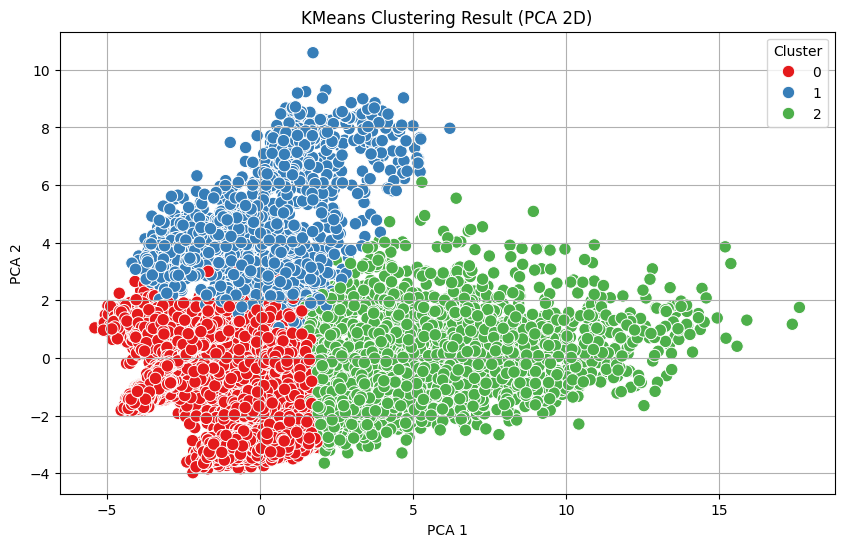

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters_kmeans,
    palette="Set1",
    s=80
)
plt.title("KMeans Clustering Result (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


# 실제 라벨 시각화

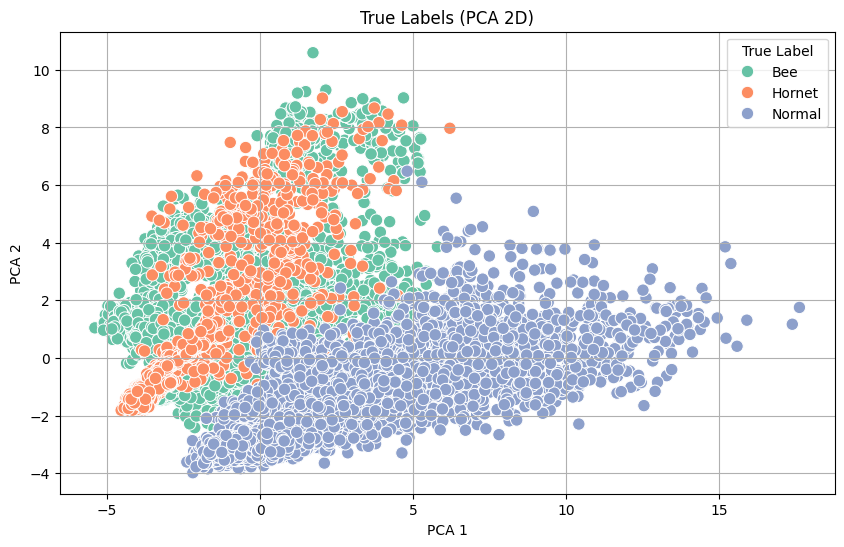

In [ ]:
label_name_reverse = {0: "Bee", 1: "Hornet", 2: "Normal"}
true_label_names = [label_name_reverse[i] for i in y_true]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=true_label_names,
    palette="Set2",
    s=80
)
plt.title("True Labels (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="True Label")
plt.grid(True)
plt.show()

# KMeans 결과와 실제 라벨 비교용 표

In [ ]:
df_result = pd.DataFrame({
    "file_name": file_names,
    "true_label": [label_name_reverse[i] for i in y_true],
    "cluster": clusters_kmeans
})

print("\n[KMeans 군집 결과 일부]")
print(df_result.head(20))

# confusion matrix 참고용
cm = confusion_matrix(y_true, clusters_kmeans)
print("\n[Confusion Matrix: true_label vs cluster]")
print(cm)


[KMeans 군집 결과 일부]
                            file_name true_label  cluster
0         output_Bee_0_Bee_0_0000.wav        Bee        1
1         output_Bee_0_Bee_0_0001.wav        Bee        1
2         output_Bee_0_Bee_0_0002.wav        Bee        1
3         output_Bee_0_Bee_0_0003.wav        Bee        1
4         output_Bee_0_Bee_0_0004.wav        Bee        1
5   output_Bee_1000_Bee_1000_0000.wav        Bee        1
6   output_Bee_1000_Bee_1000_0001.wav        Bee        1
7   output_Bee_1000_Bee_1000_0002.wav        Bee        1
8   output_Bee_1000_Bee_1000_0003.wav        Bee        1
9   output_Bee_1000_Bee_1000_0004.wav        Bee        1
10  output_Bee_1001_Bee_1001_0000.wav        Bee        0
11  output_Bee_1001_Bee_1001_0001.wav        Bee        0
12  output_Bee_1001_Bee_1001_0002.wav        Bee        0
13  output_Bee_1001_Bee_1001_0003.wav        Bee        0
14  output_Bee_1001_Bee_1001_0004.wav        Bee        0
15  output_Bee_1002_Bee_1002_0000.wav        Bee     

# DBSCAN


[DBSCAN 결과]
Cluster labels: [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158]
Silhouette Score (without noise): 0.058134996034779195


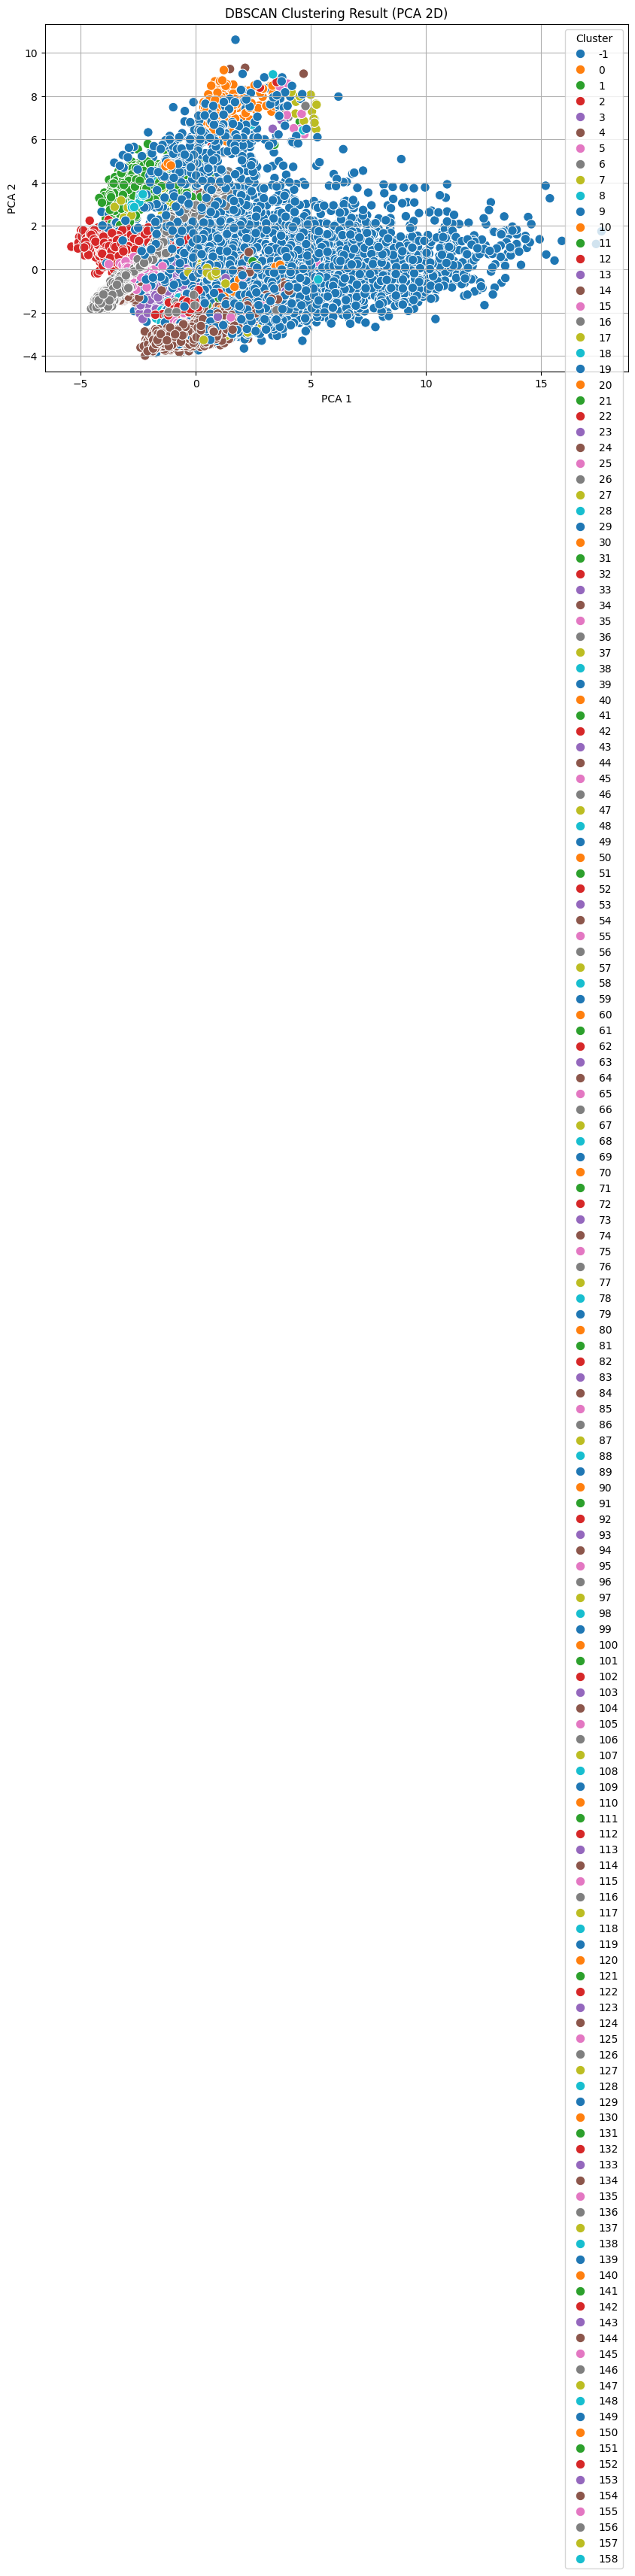

In [ ]:
dbscan = DBSCAN(eps=1.8, min_samples=4)
clusters_dbscan = dbscan.fit_predict(X_scaled)

print("\n[DBSCAN 결과]")
print("Cluster labels:", np.unique(clusters_dbscan))

# noise 제외하고 silhouette 계산
valid_mask = clusters_dbscan != -1
if len(set(clusters_dbscan[valid_mask])) > 1:
    sil_db = silhouette_score(X_scaled[valid_mask], clusters_dbscan[valid_mask])
    print("Silhouette Score (without noise):", sil_db)
else:
    print("유효한 클러스터가 부족해서 silhouette score 계산 불가")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters_dbscan,
    palette="tab10",
    s=80
)
plt.title("DBSCAN Clustering Result (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()